# Speech Emotion Recognition on CREMA-D (Classical vs Quantum)

Main Colab-ready notebook for training/evaluating classical and hybrid quantum models on CREMA-D. Supports spectrogram CNNs, MFCC CNNs, and precomputed embeddings with optional two-stage fine-tuning.


In [ ]:
!pip install pennylane torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 75.2 MB/s eta 0:00:00


In [2]:
# Colab setup: mount Drive, clone repo, checkout fine-tunning branch
import os, sys, subprocess
from pathlib import Path

REPO_URL = 'https://github.com/lburdman/qnn-transfer-learning.git'
REPO_PATH = Path('/content/qnn-transfer-learning')
BRANCH = 'fine-tunning'

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    if not REPO_PATH.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_PATH)], check=True)
    os.chdir(REPO_PATH)
    subprocess.run(['git', 'fetch'], check=True)
    subprocess.run(['git', 'checkout', BRANCH], check=True)
    subprocess.run(['git', 'pull', 'origin', BRANCH], check=True)
else:
    os.chdir(Path('.'))

sys.path.append(str(Path.cwd() / 'src'))
print('Working dir:', Path.cwd())
print('Python path updated with src/')


Mounted at /content/drive
Working dir: /content/qnn-transfer-learning
Python path updated with src/


In [3]:
import json, time, random
from pathlib import Path
from dataclasses import dataclass
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.utils import configure_run, print_model_summary
from src.dataset import create_dataloaders_all
from src.model_builder import build_model
from src.training import (
    train_with_history,
    train_model,
    evaluate_model,
    pretrain_backbone_and_embedding,
    finetune_head_only,
    summarize_experiments,
    freeze_module_params,
    FineTuneConfig,
)
from src.quantum_circuit import draw_qnode_circuit_example, analyze_trained_quantum_head

print('Imports ready')


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Imports ready


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [5]:
# Interactive configuration widgets
import ipywidgets as widgets
from IPython.display import display
base_model_dropdown = widgets.Dropdown(
    options=[('Emb ResNet18','emb_resnet18'), ('Emb VGG16','emb_vgg16'), ('Emb PANNs','emb_panns_cnn14'), ('CNN Spectrograms','cnn_specs'), ('CNN MFCC','cnn_mfcc')],
    value='emb_resnet18',
    description='Base',
)
fine_tune_toggle = widgets.ToggleButtons(options=[('Fine-tune','fine'), ('Hybrid','hybrid')], value='hybrid', description='Mode')
quantum_toggle = widgets.ToggleButtons(options=[('Classical', False), ('Quantum', True)], value=True, description='Head')
n_qubits_slider = widgets.IntSlider(value=10, min=4, max=16, step=1, description='n_qubits')
q_depth_slider = widgets.IntSlider(value=2, min=1, max=4, step=1, description='q_depth')
batch_slider = widgets.IntSlider(value=8, min=2, max=32, step=2, description='Batch')
display(widgets.VBox([base_model_dropdown, fine_tune_toggle, quantum_toggle, n_qubits_slider, q_depth_slider, batch_slider]))


In [34]:
# Experiment configuration
DATA_ROOT = '/content/drive/MyDrive/CREMAD' if 'google.colab' in sys.modules else str(Path.cwd() / 'CREMAD')
BASE_MODEL = base_model_dropdown.value if 'base_model_dropdown' in globals() else 'emb_resnet18'
USE_QUANTUM = quantum_toggle.value if 'quantum_toggle' in globals() else False
FINE_TUNING = (fine_tune_toggle.value == 'fine') if 'fine_tune_toggle' in globals() else True
SELECTED_CLASSES = ['ANG', 'SAD', 'HAP']  # e.g., ['ANG', 'SAD'] or None for all
N_QUBITS = n_qubits_slider.value if 'n_qubits_slider' in globals() else 10
Q_DEPTH = q_depth_slider.value if 'q_depth_slider' in globals() else 2
BATCH_SIZE = batch_slider.value if 'batch_slider' in globals() else 8
EPOCHS_PRETRAIN = 4
EPOCHS_FINETUNE = 25
EPOCHS = EPOCHS_FINETUNE
if FINE_TUNING:
    LR_PRETRAIN = 1e-3
    LR_FINETUNE = 4e-4
else:
    LEARNING_RATE = 1e-4 # 2e-3
RNG_SEED = 42

random.seed(RNG_SEED); np.random.seed(RNG_SEED); torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)

if FINE_TUNING:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS_FINETUNE,
        learning_rate=LR_FINETUNE,
        data_root=DATA_ROOT,
    )
    config['num_epochs_pretrain'] = EPOCHS_PRETRAIN
    config['learning_rate_pretrain'] = LR_PRETRAIN
else:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        data_root=DATA_ROOT,
    )
print(json.dumps(config, indent=2))


{
  "run_id": "12-04_16-38-00",
  "base_model": "cnn_specs",
  "quantum": false,
  "classical_model": "512_nq_2",
  "n_qubits": 8,
  "q_depth": 3,
  "selected_classes": [
    "ANG",
    "SAD",
    "HAP"
  ],
  "batch_size": 8,
  "num_epochs": 25,
  "learning_rate": 0.0001,
  "data_root": "/content/drive/MyDrive/CREMAD",
  "specs_dir": "/content/drive/MyDrive/CREMAD/Spectrograms",
  "embedding_dir": "/content/drive/MyDrive/CREMAD/Embeddings",
  "mfcc_dir": "/content/drive/MyDrive/CREMAD/MFCC",
  "rng_seed": 42,
  "save_root": "/content/drive/MyDrive/CREMAD/Models",
  "model_dir": "/content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_16-38-00"
}


In [35]:
dataloaders, dataset_sizes, class_names, counts_per_class = create_dataloaders_all(config, shuffle=True, num_workers=0)
print('Splits sizes:', dataset_sizes)
print('Classes:', class_names)
phase = 'train' if 'train' in dataloaders else list(dataloaders.keys())[0]
sample_x, sample_y = next(iter(dataloaders[phase]))
print('Sample batch shape:', sample_x.shape)
print('Label shape:', sample_y.shape)
print('Counts per class (train):', counts_per_class.get('train', {}))


Splits sizes: {'train': 2678, 'val': 717, 'test': 763}
Classes: ['ANG', 'HAP', 'SAD']
Sample batch shape: torch.Size([8, 3, 224, 224])
Label shape: torch.Size([8])
Counts per class (train): {'ANG': 890, 'HAP': 891, 'SAD': 897}


In [36]:
if USE_QUANTUM:
    try:
        draw_qnode_circuit_example(n_qubits=N_QUBITS, q_depth=Q_DEPTH, max_layers=None, seed=0)
    except Exception as exc:
        print('Quantum preview skipped:', exc)
else:
    print('Quantum preview skipped (USE_QUANTUM=False)')


Quantum preview skipped (USE_QUANTUM=False)


In [37]:
# Preview model (if buildable) before training
try:
    preview_model = build_model(config, class_names, dataloaders, device)
    print_model_summary(preview_model)
except Exception as exc:
    print('Preview model summary skipped:', exc)


Torchinfo not available; showing minimal structure:
- conv1: Conv2d
- bn1: BatchNorm2d
- relu: ReLU
- maxpool: MaxPool2d
- layer1: Sequential
- layer2: Sequential
- layer3: Sequential
- layer4: Sequential
- avgpool: AdaptiveAvgPool2d
- fc: Sequential
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [38]:
history_stage1 = {}
history_stage2 = {}
final_acc = None
best_model = None

if FINE_TUNING and BASE_MODEL == 'emb_resnet18':
    ft_cfg = FineTuneConfig(
        representation=BASE_MODEL,
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        pretrain_epochs=EPOCHS_PRETRAIN,
        finetune_epochs=EPOCHS_FINETUNE,
        learning_rate_pretrain=LR_PRETRAIN,
        learning_rate_finetune_classical=LR_FINETUNE,
        learning_rate_finetune_quantum=LR_FINETUNE,
        backbone_dir=str(Path(DATA_ROOT) / 'Models' / 'backbone'),
        batch_size=BATCH_SIZE,
        device_override=None,
    )
    stage1_model, history_stage1, checkpoint = pretrain_backbone_and_embedding(
        dataloaders, dataset_sizes, class_names, ft_cfg, representation_tag=BASE_MODEL
    )
    head_type = 'quantum' if USE_QUANTUM else 'classical'
    best_model, history_stage2, final_acc = finetune_head_only(
        checkpoint, dataloaders, dataset_sizes, class_names, ft_cfg, head_type=head_type,
        representation_tag=BASE_MODEL
    )
else:
    best_model = build_model(config, class_names, dataloaders, device=device)
    best_model, history_stage1 = train_model(
        best_model, dataloaders, dataset_sizes, device, config['num_epochs'], config['learning_rate'], config['model_dir']
    )
    final_acc = history_stage1.get('test_acc', [0])[-1] if history_stage1.get('test_acc') else 0
print('Final test acc estimate:', f'{final_acc:.4f}')


Epoch 1/25
------------------------------


train 1/25:   0%|          | 0/335 [00:00<?, ?it/s]

train Loss: 0.7090  Acc: 0.6819  F1: 0.6803


test 1/25:   0%|          | 0/96 [00:00<?, ?it/s]

test Loss: 0.5580  Acc: 0.7641  F1: 0.7605

Epoch 2/25
------------------------------


...

test Loss: 0.7524  Acc: 0.8100  F1: 0.8081

Epoch 25/25
------------------------------


train 25/25:   0%|          | 0/335 [00:00<?, ?it/s]

train Loss: 0.0079  Acc: 0.9985  F1: 0.9985


test 25/25:   0%|          | 0/96 [00:00<?, ?it/s]

test Loss: 0.7440  Acc: 0.8204  F1: 0.8174

Training complete. Best test accuracy: 0.8218
Model saved to /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_16-38-00/model.pt
Final test acc estimate: 0.8204


In [39]:
# Model summary
print_model_summary(best_model)


Torchinfo not available; showing minimal structure:
- conv1: Conv2d
- bn1: BatchNorm2d
- relu: ReLU
- maxpool: MaxPool2d
- layer1: Sequential
- layer2: Sequential
- layer3: Sequential
- layer4: Sequential
- avgpool: AdaptiveAvgPool2d
- fc: Sequential
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

Saved plot to /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_16-38-00/stage1_metrics.png


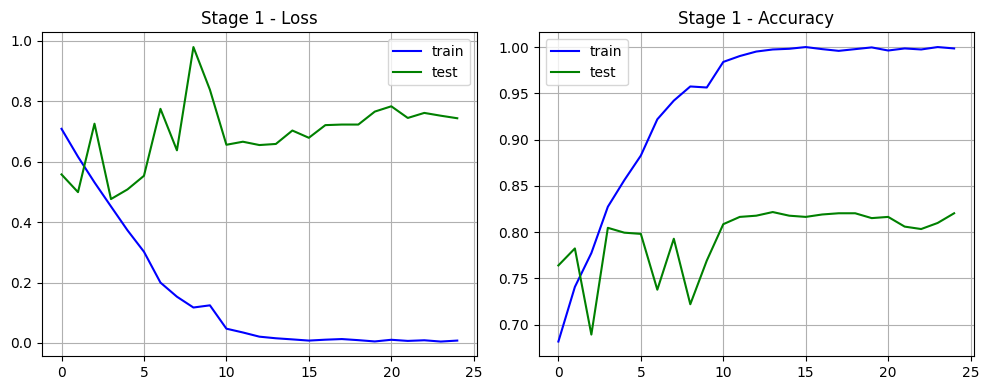

In [40]:
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    for phase, color in [('train','blue'), ('test','green')]:
        if f'{phase}_loss' in history:
            axes[0].plot(history[f'{phase}_loss'], label=f'{phase}', color=color)
        if f'{phase}_acc' in history:
            axes[1].plot(history[f'{phase}_acc'], label=f'{phase}', color=color)
    axes[0].set_title(f'{title} - Loss'); axes[1].set_title(f'{title} - Accuracy')
    for ax in axes:
        ax.legend(); ax.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print('Saved plot to', save_path)
    plt.show()

plot_history(history_stage1, 'Stage 1', save_path=Path(config['model_dir'])/'stage1_metrics.png')
if history_stage2:
    plot_history(history_stage2, 'Stage 2', save_path=Path(config['model_dir'])/'stage2_metrics.png')


In [41]:
metrics = {}
if 'val' in dataloaders:
    metrics['val'] = evaluate_model(best_model, dataloaders['val'], class_names, device, config['model_dir'], split_name='val')
if 'test' in dataloaders:
    metrics['test'] = evaluate_model(best_model, dataloaders['test'], class_names, device, config['model_dir'], split_name='test')
for split, vals in metrics.items():
    acc = vals.get('accuracy', 0)
    f1 = vals.get('f1_weighted', 0)
    print(f'{split.upper()} accuracy: {acc:.4f}, F1: {f1:.4f}')
print(metrics)


Evaluating (val):   0%|          | 0/90 [00:00<?, ?it/s]

VAL metrics saved to /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_16-38-00/val_metrics.json
VAL Accuracy: 0.8061 | F1: 0.8007
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_16-38-00/confusion_matrix_val.png


Evaluating (test):   0%|          | 0/96 [00:00<?, ?it/s]

TEST metrics saved to /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_16-38-00/test_metrics.json
TEST Accuracy: 0.8204 | F1: 0.8174
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_16-38-00/confusion_matrix_test.png
VAL accuracy: 0.8061, F1: 0.8007
TEST accuracy: 0.8204, F1: 0.8174
{'val': {'accuracy': 0.806136680613668, 'precision_weighted': 0.8073848816506559, 'recall_weighted': 0.806136680613668, 'f1_weighted': 0.8007306436185547}, 'test': {'accuracy': 0.8204456094364351, 'precision_weighted': 0.8201029607320635, 'recall_weighted': 0.8204456094364351, 'f1_weighted': 0.8173538278696665}}


In [42]:
if USE_QUANTUM:
    try:
        analyze_trained_quantum_head(best_model, device=device, sample_input=None, print_density=True, save_dir=config.get("model_dir"))
    except Exception as exc:
        print('Quantum recap failed:', exc)
else:
    print('Quantum recap skipped (USE_QUANTUM=False)')


Quantum recap skipped (USE_QUANTUM=False)
